# EWAT — Génération et collecte du dataset (données réelles)

Ce notebook documente **comment** le dataset EWAT est produit, étape par étape, en
montrant à chaque fois la **donnée brute** correspondante (rien n'est simulé,
toutes les valeurs viennent de `data/raw/` et `data/features/v3/`).

**Plan**

1. Vue d'ensemble — combien d'épisodes, quels scénarios
2. Un épisode = 4 dumps bruts (manifest, episode.json, prometheus, jaeger, loki)
3. Frontières temporelles d'un épisode (baseline / pre / injection / recovery)
4. **Prometheus brut** — 11 séries × pods × ~45 points (step 15s)
5. **Jaeger brut** — 1 842 traces complètes (spans, refs, durées µs)
6. **Loki brut** — 2 958 lignes log avec labels k8s complets
7. Phase 2 : construction de S(t) ∈ ℝ^{T×N×17} depuis les dumps
8. Visualisation du signal S(t) sur un épisode (heatmap + courbes)
9. Visualisation du graphe G(t) (matrice d'adjacence pondérée)
10. Comparaison de signatures normal vs injection sur plusieurs scénarios

> Workdir attendu : racine du repo. Si vous lancez depuis `notebooks/`, le path
> `ROOT = Path('..')` ci-dessous résout automatiquement vers la racine.


In [179]:
import sys, gzip, json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Résolution robuste de la racine du repo (qu'on soit dans notebooks/ ou à la racine)
HERE = Path.cwd()
ROOT = HERE if (HERE / 'src' / 'ewat').exists() else HERE.parent
sys.path.insert(0, str(ROOT))

RAW = ROOT / 'data' / 'raw'
FEAT = ROOT / 'data' / 'features' / 'v3'
print('ROOT :', ROOT)
print('RAW  :', RAW, '— exists:', RAW.exists())
print('FEAT :', FEAT, '— exists:', FEAT.exists())

ROOT : /home/wassimbadraoui/repos/ewat
RAW  : /home/wassimbadraoui/repos/ewat/data/raw — exists: True
FEAT : /home/wassimbadraoui/repos/ewat/data/features/v3 — exists: True


## 1. Vue d'ensemble du dataset brut

303 épisodes dans `data/raw/` pour ewat_v3, regroupés par **scénario Chaos Mesh**.
Chaque scénario est répliqué ~20 fois pour donner du signal statistique.


In [180]:
episodes = sorted(p for p in RAW.iterdir() if p.is_dir() and p.name.startswith('episode_'))
print(f'Total épisodes : {len(episodes)}')

# Nom de scénario = tout ce qui est entre 'episode_' et '_<num>_<ts>'
def scenario_of(name: str) -> str:
    parts = name.split('_')
    return '_'.join(parts[1:-2])

scenarios = Counter(scenario_of(e.name) for e in episodes)
df_scen = pd.DataFrame(sorted(scenarios.items()), columns=['scenario', 'n_episodes'])
df_scen

Total épisodes : 300


,scenario,n_episodes
0,cpu_starvation,20
1,crash,20
2,drift_config_change,20
3,drift_rolling_deploy,20
4,drift_scale_up,20
5,drift_traffic_ramp,20
6,fail_slow_cpu,20
7,fail_slow_latency,20
8,faulty_deploy_overlap,20
9,intermittent_error,20


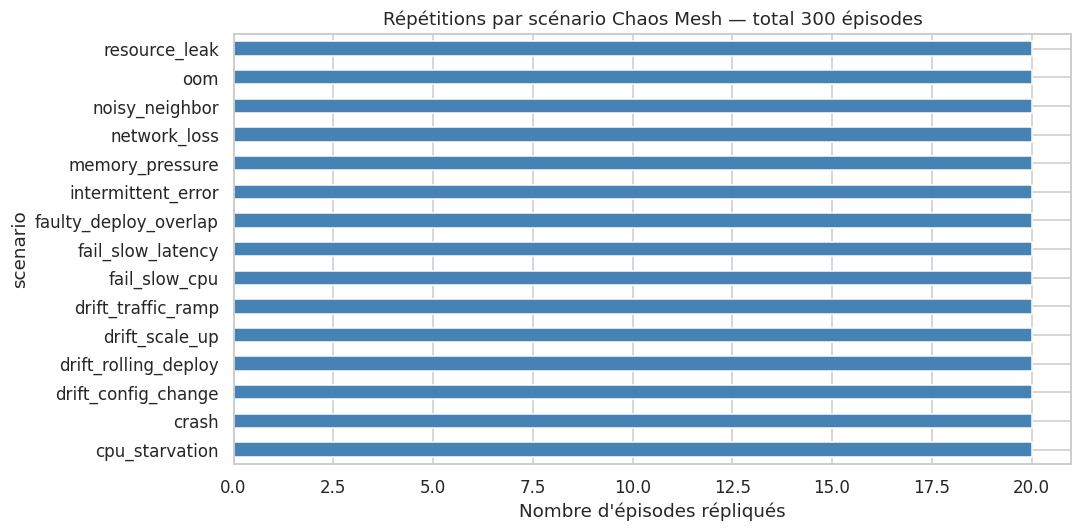

In [181]:
fig, ax = plt.subplots(figsize=(10, 5))
df_scen.sort_values('n_episodes').plot.barh(x='scenario', y='n_episodes',
                                            ax=ax, color='steelblue', legend=False)
ax.set_title(f"Répétitions par scénario Chaos Mesh — total {len(episodes)} épisodes")
ax.set_xlabel("Nombre d'épisodes répliqués")
plt.tight_layout()
plt.show()

## 2. Anatomie d'un épisode — 4 dumps bruts

On prend un épisode `cpu_starvation` pour la suite. Chaque épisode est un dossier
contenant **toujours la même structure** :

```
episode_<scenario>_<rep>_<UTCstamp>/
├── episode.json              # frontières temporelles + métadonnées scénario
├── manifest.json             # hash SHA256 de chaque dump (provenance / audit)
├── prometheus_range.json.gz  # 11 séries range-query × pods × ~45 points
├── jaeger_spans.json.gz      # traces complètes (parents, durées µs, tags Envoy)
└── loki_logs.json.gz         # lignes log brutes + 20+ labels k8s/OTel
```


In [182]:
EP = sorted(RAW.glob('episode_cpu_starvation_*'))[0]
print('Épisode choisi :', EP.name)
for f in sorted(EP.iterdir()):
    print(f'  {f.name:30s}  {f.stat().st_size/1024:8.1f} KB')

Épisode choisi : episode_cpu_starvation_000_20260430T022941Z
  episode.json                         3.3 KB
  jaeger_spans.json.gz              2698.9 KB
  loki_logs.json.gz                  211.9 KB
  manifest.json                        1.8 KB
  prometheus_range.json.gz            48.6 KB


In [183]:
# manifest.json — provenance + hash SHA256
manifest = json.loads((EP / 'manifest.json').read_text())
print(json.dumps(manifest, indent=2)[:1500])

{
  "sources": {
    "prometheus": {
      "path": "prometheus_range.json.gz",
      "size_bytes": 49757,
      "sha256": "4b2c8523cd6ba59642e1622e855efbea105f27aa8c6bcd6f9a73981cc28077c8",
      "elapsed_s": 0.30465221405029297,
      "errors": {},
      "queries_ok": [
        "cpu_limit",
        "cpu_usage",
        "disk_iops",
        "grpc_request_duration_bucket",
        "http_request_duration_bucket",
        "http_requests_errors",
        "http_requests_total",
        "net_transmit_bytes",
        "queue_depth",
        "ram_limit",
        "ram_usage"
      ],
      "fallback_used": {
        "cpu_usage": false,
        "cpu_limit": false,
        "ram_usage": false,
        "ram_limit": false,
        "http_request_duration_bucket": true,
        "http_requests_total": true,
        "http_requests_errors": true,
        "grpc_request_duration_bucket": false,
        "net_transmit_bytes": false,
        "disk_iops": false,
        "queue_depth": true
      },
      "fetch

In [184]:
# episode.json — scénario + frontières temporelles + cluster
episode_meta = json.loads((EP / 'episode.json').read_text())
print('Scénario        :', episode_meta['scenario']['name'])
print('Description     :', episode_meta['scenario']['description'])
print('Cibles chaos    :', episode_meta['scenario']['targets'])
print('Services (N=6)  :', episode_meta['canonical_services'])
print('Cluster         :', episode_meta['cluster']['name'])
print()
print('Frontières temporelles (unix s) :')
for k, v in episode_meta['boundaries'].items():
    ts = pd.Timestamp(v, unit='s', tz='UTC')
    print(f"  {k:25s} {v:.2f}   ({ts})")

Scénario        : cpu_starvation
Description     : Heavy CPU stress (4 workers, 100% load)
Cibles chaos    : ['frontend', 'checkout']
Services (N=6)  : ['frontend', 'recommendation', 'cart', 'ad', 'product-catalog', 'load-generator']
Cluster         : observit-cluster1

Frontières temporelles (unix s) :
  baseline_start            1777516181.96   (2026-04-30 02:29:41.964859486+00:00)
  baseline_end              1777516481.96   (2026-04-30 02:34:41.964996815+00:00)
  pre_start                 1777516481.96   (2026-04-30 02:34:41.964996815+00:00)
  pre_end                   1777516541.97   (2026-04-30 02:35:41.965132475+00:00)
  injection_start           1777516541.97   (2026-04-30 02:35:41.965132475+00:00)
  apply_returned_at         1777516543.67   (2026-04-30 02:35:43.668907166+00:00)
  injection_end             1777516723.67   (2026-04-30 02:38:43.669039726+00:00)
  delete_returned_at        1777516724.29   (2026-04-30 02:38:44.288288593+00:00)
  recovery_start            1777516724.

### 2.1 Visualisation des frontières temporelles

Chaque épisode = **4 phases successives** :

- **baseline** (5 min) — état nominal, sert de référence
- **pre-injection** (1 min) — fenêtre pour les précurseurs (H3)
- **injection** (3 min) — Chaos Mesh actif
- **recovery** (2 min) — retour vers la normale

Total ~11 min échantillonné à 15s → ~44 pas en théorie, ~21 retenus après
filtrage des NaN de bord.


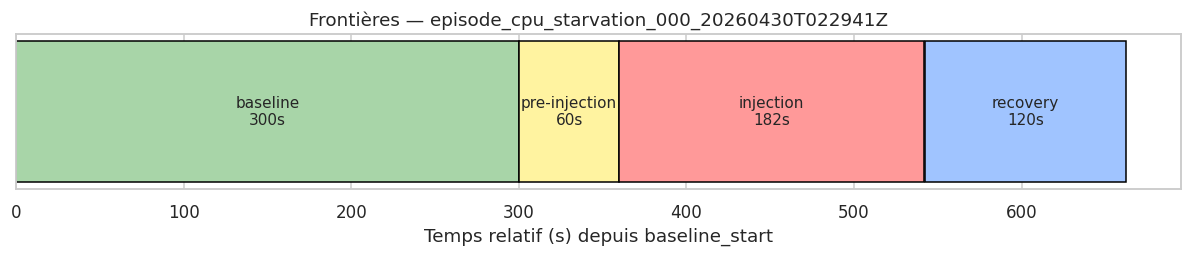

In [185]:
b = episode_meta['boundaries']
t0 = b['baseline_start']
phases = [
    ('baseline',      b['baseline_start']  - t0, b['baseline_end']  - t0, '#a8d5a8'),
    ('pre-injection', b['pre_start']       - t0, b['pre_end']       - t0, '#fff3a0'),
    ('injection',     b['injection_start'] - t0, b['injection_end'] - t0, '#ff9999'),
    ('recovery',      b['recovery_start']  - t0, b['recovery_end']  - t0, '#a0c4ff'),
]

fig, ax = plt.subplots(figsize=(11, 2.5))
for name, start, end, color in phases:
    ax.barh(0, end - start, left=start, color=color, edgecolor='black')
    ax.text((start + end) / 2, 0, f'{name}\n{end-start:.0f}s',
            ha='center', va='center', fontsize=10)
ax.set_yticks([])
ax.set_xlabel('Temps relatif (s) depuis baseline_start')
ax.set_title(f'Frontières — {EP.name}')
plt.tight_layout()
plt.show()

## 3. Prometheus — données brutes

11 PromQL range-queries sont exécutées contre `cattle-monitoring-system/prometheus`
(port-forward `localhost:19090`). Chaque requête retourne **N séries** (une par pod
match) × **45 points** au pas de 15s.

Les templates PromQL sont dans `src/telemetry/prom_queries.py`. Chaque requête a
un **fallback OTel** si la série Istio est vide.


In [186]:
with gzip.open(EP / 'prometheus_range.json.gz') as f:
    prom = json.load(f)

print('Endpoint           :', prom['endpoint'])
print('Window (rate)      :', prom['window'])
print('Step (s)           :', prom['step_s'])
print('Plage (s)          :', prom['end_unix_s'] - prom['start_unix_s'])
print()
print('Requêtes exécutées :')
for q in prom['results']:
    n_series = len(prom['results'][q].get('data', {}).get('result', []))
    fb = prom['fallback_used'].get(q, False)
    print(f'  {q:35s}  n_series={n_series:3d}  fallback_used={fb}')

Endpoint           : http://172.16.203.12:31090
Window (rate)      : 2m
Step (s)           : 15
Plage (s)          : 662.3236064910889

Requêtes exécutées :
  cpu_usage                            n_series= 23  fallback_used=False
  cpu_limit                            n_series=  0  fallback_used=False
  ram_usage                            n_series= 23  fallback_used=False
  ram_limit                            n_series=153  fallback_used=False
  http_request_duration_bucket         n_series= 32  fallback_used=True
  http_requests_total                  n_series=  2  fallback_used=True
  http_requests_errors                 n_series=  2  fallback_used=True
  grpc_request_duration_bucket         n_series= 32  fallback_used=False
  net_transmit_bytes                   n_series= 24  fallback_used=False
  disk_iops                            n_series= 20  fallback_used=False
  queue_depth                          n_series= 36  fallback_used=True


In [187]:
# Une série brute : cpu_usage pour un pod précis
r = prom['results']['cpu_usage']['data']['result']
print(f'cpu_usage : {len(r)} séries (= {len(r)} pods qui ont matché)')
print()
print('--- Série 0, labels Prometheus :')
print(r[0]['metric'])
print()
print("--- Série 0, 5 premiers points [unix_ts, value_str] :")
for ts, v in r[0]['values'][:5]:
    print(f'  {ts:.3f}  →  {float(v):.6f}  (cpu cores)')
print('  … total :', len(r[0]['values']), 'points')

cpu_usage : 23 séries (= 23 pods qui ont matché)

--- Série 0, labels Prometheus :
{'namespace': 'ewat', 'pod': 'accounting-5bcc7d46ff-h2gxh'}

--- Série 0, 5 premiers points [unix_ts, value_str] :
  1777516181.965  →  0.002979  (cpu cores)
  1777516196.965  →  0.002882  (cpu cores)
  1777516211.965  →  0.003048  (cpu cores)
  1777516226.965  →  0.003105  (cpu cores)
  1777516241.965  →  0.003076  (cpu cores)
  … total : 45 points


### 3.1 Échantillon **100% brut** — directement extrait du `.json.gz`

Aucune transformation : on imprime le contenu exact du fichier Prometheus tel
qu'il est stocké sur disque (extrait de la première série, format API Prom natif).


In [188]:
raw_prom_sample = {
    'status': prom['results']['cpu_usage']['status'],
    'data': {
        'resultType': prom['results']['cpu_usage']['data'].get('resultType'),
        'result': [prom['results']['cpu_usage']['data']['result'][0]],  # 1 série complète
    },
}
print(json.dumps(raw_prom_sample, indent=2)[:2500])
print('... (' + str(len(prom['results']['cpu_usage']['data']['result'][0]['values'])) + ' points au total)')

{
  "status": "success",
  "data": {
    "resultType": "matrix",
    "result": [
      {
        "metric": {
          "namespace": "ewat",
          "pod": "accounting-5bcc7d46ff-h2gxh"
        },
        "values": [
          [
            1777516181.965,
            "0.0029792159447815003"
          ],
          [
            1777516196.965,
            "0.0028821041964146553"
          ],
          [
            1777516211.965,
            "0.003048186448806151"
          ],
          [
            1777516226.965,
            "0.0031046128809007617"
          ],
          [
            1777516241.965,
            "0.003075932420711737"
          ],
          [
            1777516256.965,
            "0.0032076061423809725"
          ],
          [
            1777516271.965,
            "0.003350148282789584"
          ],
          [
            1777516286.965,
            "0.0033214559093724056"
          ],
          [
            1777516301.965,
            "0.003331927974572468

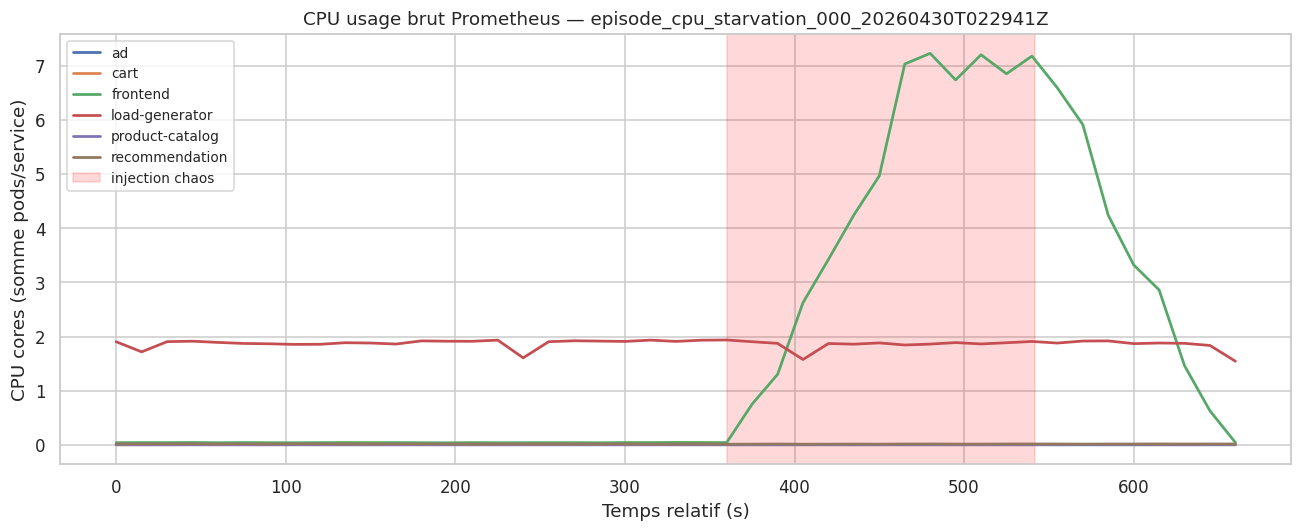

In [189]:
# Tracé : CPU brut pour TOUS les pods canoniques (agrégés par service)
def series_to_df(series_list):
    rows = []
    for s in series_list:
        pod = s['metric'].get('pod') or s['metric'].get('k8s_pod_name', '?')
        for ts, v in s['values']:
            rows.append({'pod': pod, 'ts': float(ts), 'value': float(v)})
    return pd.DataFrame(rows)

df_cpu = series_to_df(r)
df_cpu['t_rel'] = df_cpu['ts'] - prom['start_unix_s']
keep = tuple(episode_meta['canonical_services'])
df_cpu['service'] = df_cpu['pod'].apply(lambda p: next((s for s in keep if p.startswith(s)), 'other'))
df_canon = df_cpu[df_cpu['service'] != 'other']

fig, ax = plt.subplots(figsize=(12, 5))
for service, sub in df_canon.groupby('service'):
    agg = sub.groupby('t_rel')['value'].sum()
    ax.plot(agg.index, agg.values, label=service, linewidth=1.8)
inj_s = episode_meta['boundaries']['injection_start'] - prom['start_unix_s']
inj_e = episode_meta['boundaries']['injection_end']   - prom['start_unix_s']
ax.axvspan(inj_s, inj_e, color='red', alpha=0.15, label='injection chaos')
ax.set_xlabel('Temps relatif (s)')
ax.set_ylabel('CPU cores (somme pods/service)')
ax.set_title(f'CPU usage brut Prometheus — {EP.name}')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Jaeger — traces brutes

Les traces distribuées sont récupérées via l'API HTTP Jaeger
(`rca-sandbox/jaeger-query:16686`) avec une limite de 1500 traces/service.
**Aucune information n'est jetée** : on conserve les parents (`references`),
tags Envoy, durées µs, status codes.


In [190]:
with gzip.open(EP / 'jaeger_spans.json.gz') as f:
    jaeger = json.load(f)

print('Endpoint            :', jaeger['endpoint'])
print('Services interrogés :', jaeger['services_queried'])
print('Total traces        :', len(jaeger['traces']))
print()
print('Traces par service (côté serveur racine) :')
for svc, n in jaeger['per_service_counts'].items():
    print(f'  {svc:25s} {n:5d}')

Endpoint            : http://172.16.203.12:31686
Services interrogés : ['frontend', 'recommendation', 'cart', 'ad', 'product-catalog', 'load-generator']
Total traces        : 1842

Traces par service (côté serveur racine) :
  frontend                    559
  recommendation               71
  cart                        149
  ad                           54
  product-catalog             350
  load-generator              659


In [191]:
trace0 = jaeger['traces'][0]
span0 = trace0['spans'][0]
print(f'traceID    : {trace0["traceID"]}')
print(f'nb spans   : {len(trace0["spans"])}')
print()
print('--- Span 0 (extrait) ---')
print(f'  operationName : {span0["operationName"]}')
print(f'  spanID        : {span0["spanID"]}')
print(f'  startTime (µs): {span0["startTime"]}')
print(f'  duration (µs) : {span0["duration"]}')
print(f'  references    : {span0.get("references")}')
print(f'  tags (5 prem) :')
for tag in span0['tags'][:5]:
    print(f'    {tag["key"]:25s} = {tag["value"]}')

traceID    : e882a370a420906c427d390f5252a622
nb spans   : 10

--- Span 0 (extrait) ---
  operationName : router frontend egress
  spanID        : e8d6983254a8d7d9
  startTime (µs): 1777516830669302
  duration (µs) : 9220
  references    : [{'refType': 'CHILD_OF', 'traceID': 'e882a370a420906c427d390f5252a622', 'spanID': '5333ede104d54077'}]
  tags (5 prem) :
    otel.scope.name           = envoy
    otel.scope.version        = 5251fec52ee063192dcd8bd0615c6283e7b12b6c/1.34.12/Clean/RELEASE/BoringSSL
    component                 = proxy
    http.protocol             = HTTP/1.1
    http.status_code          = 200


### 4.1 Échantillon **100% brut** — un span complet exactement comme dumpé

Aucune transformation : c'est le span tel que renvoyé par l'API Jaeger
(`/api/traces`) et stocké tel quel dans `jaeger_spans.json.gz`.


In [192]:
# Un span entier (avec tous ses tags, refs, logs, processID)
print('=== SPAN BRUT (format Jaeger natif) ===')
print(json.dumps(span0, indent=2))
print()
print('=== Le \"process\" associé (resolved via processID) ===')
print(json.dumps(trace0['processes'].get(span0['processID']), indent=2))

=== SPAN BRUT (format Jaeger natif) ===
{
  "traceID": "e882a370a420906c427d390f5252a622",
  "spanID": "e8d6983254a8d7d9",
  "operationName": "router frontend egress",
  "references": [
    {
      "refType": "CHILD_OF",
      "traceID": "e882a370a420906c427d390f5252a622",
      "spanID": "5333ede104d54077"
    }
  ],
  "startTime": 1777516830669302,
  "duration": 9220,
  "tags": [
    {
      "key": "otel.scope.name",
      "type": "string",
      "value": "envoy"
    },
    {
      "key": "otel.scope.version",
      "type": "string",
      "value": "5251fec52ee063192dcd8bd0615c6283e7b12b6c/1.34.12/Clean/RELEASE/BoringSSL"
    },
    {
      "key": "component",
      "type": "string",
      "value": "proxy"
    },
    {
      "key": "http.protocol",
      "type": "string",
      "value": "HTTP/1.1"
    },
    {
      "key": "http.status_code",
      "type": "string",
      "value": "200"
    },
    {
      "key": "peer.address",
      "type": "string",
      "value": "10.43.198.111:80

17805 spans, 6 services canoniques


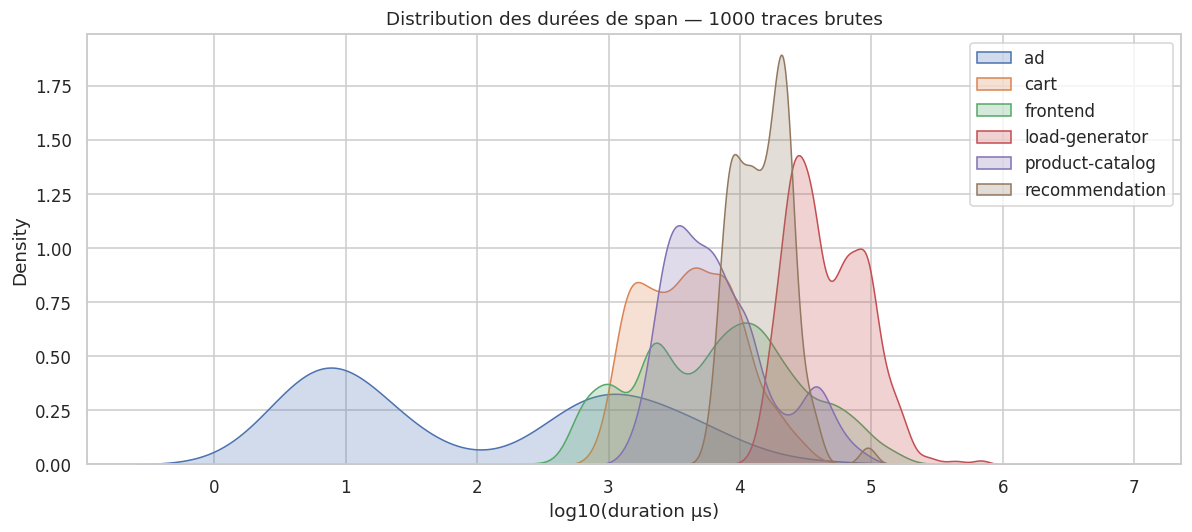

In [193]:
# Distribution des durées de span (µs) — sur 1000 traces brutes
durations, svc_of = [], []
for trace in jaeger['traces'][:1000]:
    procs = trace.get('processes', {})
    for span in trace['spans']:
        pid = span.get('processID')
        svc = procs.get(pid, {}).get('serviceName', '?')
        durations.append(span['duration'])
        svc_of.append(svc)

df_spans = pd.DataFrame({'service': svc_of, 'duration_us': durations})
df_spans = df_spans[df_spans['service'].isin(episode_meta['canonical_services'])]
print(f'{len(df_spans)} spans, {df_spans["service"].nunique()} services canoniques')

fig, ax = plt.subplots(figsize=(11, 5))
for svc, sub in df_spans.groupby('service'):
    sns.kdeplot(np.log10(sub['duration_us'].clip(lower=1)), label=svc, ax=ax, fill=True, alpha=0.25)
ax.set_xlabel('log10(duration µs)')
ax.set_title('Distribution des durées de span — 1000 traces brutes')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Loki — logs bruts

Lignes de log applicatives via l'API Loki (`monitoring-logs/loki-gateway`), limite
5000 lignes par épisode. Chaque ligne arrive avec **20+ labels** OTel/k8s (pod,
container, severity, span_id, trace_id…) plus le message texte intégral.


In [194]:
with gzip.open(EP / 'loki_logs.json.gz') as f:
    loki = json.load(f)

print('Endpoint        :', loki['endpoint'])
print('Nombre de lignes:', loki['n_lines'])
print('Truncated       :', loki['truncated'])
print('Nombre de stream:', len(loki['streams']))
print()
print('--- Premier stream, labels (échantillon) ---')
labels0 = loki['streams'][0]['labels']
for k in list(labels0)[:14]:
    print(f'  {k:30s} = {labels0[k]}')

Endpoint        : http://172.16.203.12:31100
Nombre de lignes: 2958
Truncated       : False
Nombre de stream: 2843

--- Premier stream, labels (échantillon) ---
  app_product_id                 = 0PUK6V6EV0
  app_product_name               = Solar System Color Imager
  detected_level                 = INFO
  flags                          = 1
  k8s_container_name             = product-catalog
  k8s_deployment_name            = product-catalog
  k8s_namespace_name             = ewat
  k8s_node_name                  = observit-cluster1-workers-58w74-jnk2v
  k8s_pod_name                   = product-catalog-8c7bf9d4d-m62p9
  k8s_pod_uid                    = 2a4f4aba-52b1-43c7-b1aa-4b35ae438521
  observed_timestamp             = 1777516189222736267
  scope_name                     = product-catalog
  service_name                   = product-catalog
  service_namespace              = ewat


### 5.1 Échantillon **100% brut** — une ligne de log exactement comme dumpée

Aucune transformation : structure native Loki = `{labels: {...}, values: [[ts_ns, msg], ...]}`.


In [195]:
s0 = loki['streams'][0]
print('=== STREAM BRUT (format Loki natif) ===')
print(json.dumps(s0, indent=2))
print()
# Quelques exemples de messages texte sur d'autres streams
print('=== Échantillon de messages bruts (premier value de 10 streams) ===')
for st in loki['streams'][:10]:
    sev = st['labels'].get('severity_text', '?')
    svc = st['labels'].get('service_name', '?')
    if st.get('values'):
        ts_ns, msg = st['values'][0]
        print(f'  [{sev:6s}] {svc:18s} ts_ns={ts_ns}  →  {msg[:120]}')

=== STREAM BRUT (format Loki natif) ===
{
  "labels": {
    "app_product_id": "0PUK6V6EV0",
    "app_product_name": "Solar System Color Imager",
    "detected_level": "INFO",
    "flags": "1",
    "k8s_container_name": "product-catalog",
    "k8s_deployment_name": "product-catalog",
    "k8s_namespace_name": "ewat",
    "k8s_node_name": "observit-cluster1-workers-58w74-jnk2v",
    "k8s_pod_name": "product-catalog-8c7bf9d4d-m62p9",
    "k8s_pod_uid": "2a4f4aba-52b1-43c7-b1aa-4b35ae438521",
    "observed_timestamp": "1777516189222736267",
    "scope_name": "product-catalog",
    "service_name": "product-catalog",
    "service_namespace": "ewat",
    "severity_number": "9",
    "severity_text": "INFO",
    "span_id": "a73c23a4e50b088a",
    "telemetry_sdk_language": "go",
    "telemetry_sdk_name": "opentelemetry",
    "telemetry_sdk_version": "1.39.0",
    "trace_id": "1ee26795498264d1f5b4b0b5d4cb47af"
  },
  "values": [
    [
      "1777516189222730380",
      "Product Found"
    ]
  ]
}

severity         INFO  Information  UNKNOWN
service                                    
ad                108            0        0
cart                0          205        0
frontend-proxy      0            0      700
load-generator    568            0        0
product-catalog   634            0        0
product-reviews   465            0      207
recommendation     71            0        0


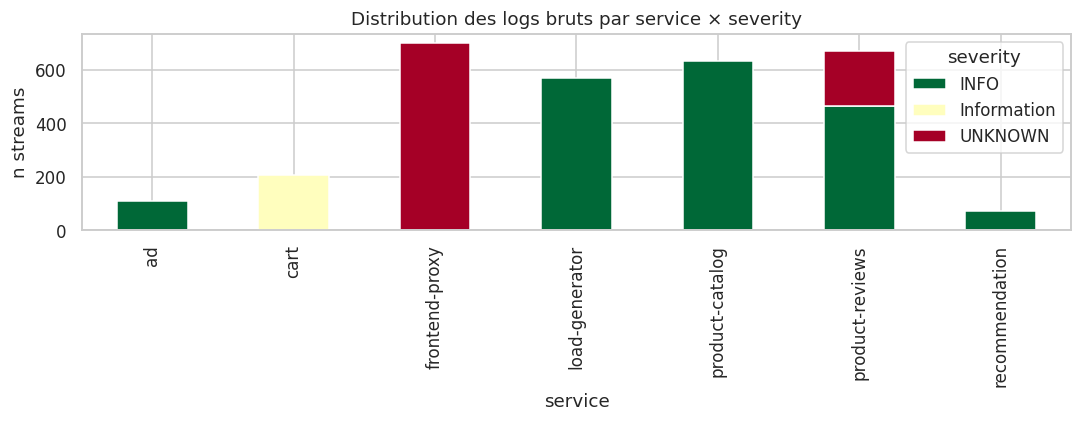

In [196]:
# Décompte par severity × service (sur la totalité des streams)
rows = []
for stream in loki['streams']:
    sev = stream['labels'].get('severity_text', 'UNKNOWN')
    svc = stream['labels'].get('service_name', '?')
    # Le format Loki utilise 'values' (pas 'entries'); chaque value = [ts_ns, message]
    n = len(stream.get('values', []))
    rows.append({'severity': sev, 'service': svc, 'n': n})

df_log = pd.DataFrame(rows)
piv = df_log.groupby(['service', 'severity'])['n'].sum().unstack(fill_value=0)
print(piv)

fig, ax = plt.subplots(figsize=(10, 4))
piv.plot.bar(stacked=True, ax=ax, colormap='RdYlGn_r')
ax.set_title('Distribution des logs bruts par service × severity')
ax.set_ylabel('n streams')
plt.tight_layout()
plt.show()

## 6. Phase 2 — construction de S(t) ∈ ℝ^{T×N×17}

Le script `scripts/build_features.py` lit les 3 dumps bruts (Prometheus + Jaeger +
Loki), applique les **règles d'agrégation différenciées** (max,
volume_weighted, p99_union, median — cf. `src/telemetry/feature_names.py`) et
produit par épisode :

```
data/features/v3/<episode>/
├── signal.npz             # tenseur S(t) shape (T, N, 17)
├── adjacency.npz          # G(t) shape (T, N, N, 3) [volume, latence, error]
├── labels.parquet         # régime + drift_flag par pas de temps
├── services.json          # ordre canonique des N services
├── signal_mask.npz        # masque NaN (transparence : on garde les trous)
├── graph_stats.csv        # stats du graphe par pas
└── feature_provenance.json
```

**Garantie de transparence** : la Phase 2 est déterministe et reproductible —
on peut la relancer avec d'autres formules sans recollecter les dumps bruts.


In [197]:
FEAT_EP = FEAT / EP.name
print('Features :', FEAT_EP)
for f in sorted(FEAT_EP.iterdir()):
    print(f'  {f.name:30s}  {f.stat().st_size/1024:8.1f} KB')

services = json.loads((FEAT_EP / 'services.json').read_text())
print('\nServices (ordre N=6) :', services)

with np.load(FEAT_EP / 'signal.npz') as z:
    S = z['signal']
print(f'\nS(t) shape : {S.shape}  (T pas × N services × 17 features)')
print(f'    dtype  : {S.dtype}')

with np.load(FEAT_EP / 'adjacency.npz') as z:
    A = z[list(z.keys())[0]]
print(f'G(t) shape : {A.shape}  (T × N × N × 3 [volume, latence, error])')

labels = pd.read_parquet(FEAT_EP / 'labels.parquet')
print(f'\nlabels.parquet shape : {labels.shape}')
print(labels.head(8))

Features : /home/wassimbadraoui/repos/ewat/data/features/v3/episode_cpu_starvation_000_20260430T022941Z
  adjacency.npz                        1.2 KB
  feature_provenance.json              0.9 KB
  graph_stats.csv                      4.0 KB
  labels.parquet                       6.5 KB
  metadata.json                       10.0 KB
  services.json                        0.1 KB
  signal.npz                           5.0 KB
  signal_mask.npz                      0.3 KB

Services (ordre N=6) : ['ad', 'cart', 'frontend', 'load-generator', 'product-catalog', 'recommendation']

S(t) shape : (23, 6, 17)  (T pas × N services × 17 features)
    dtype  : float32
G(t) shape : (23, 6, 6, 3)  (T × N × N × 3 [volume, latence, error])

labels.parquet shape : (23, 10)
      timestamp  regime    category        scenario           target_services  \
0  1.777516e+09  normal  contention  cpu_starvation  ["frontend", "checkout"]   
1  1.777516e+09  normal  contention  cpu_starvation  ["frontend", "checkout

### 6.1 Les 17 features — table

| Bloc | Idx | Feature | Agrégation pod→service |
|---|---|---|---|
| **M(t)** métriques | 0 | `cpu_util` | max |
| | 1 | `ram_util` | max |
| | 2 | `latency_p99` | p99_union |
| | 3 | `error_rate_http` | volume_weighted |
| | 4 | `net_sat` | max |
| | 5 | `disk_io` | max |
| | 6 | `queue_depth` | max |
| **T(t)** traces | 7 | `span_dur_p99` | p99_union |
| | 8 | `abnormal_span_rate` | volume_weighted |
| | 9 | `trace_depth` | median |
| | 10 | `fan_out` | median |
| | 11 | `retry_rate` | volume_weighted |
| | 12 | `latency_cv` | median |
| **L(t)** logs | 13 | `log_error_rate` | volume_weighted |
| | 14 | `log_warn_rate` | volume_weighted |
| | 15 | `semantic_anomaly` | median |
| | 16 | `lexical_entropy` | median |


In [198]:
from src.telemetry.feature_names import (
    FEATURE_NAMES, METRICS_SLICE, TRACES_SLICE, LOGS_SLICE, AGGREGATION_RULE
)
print('FEATURE_NAMES =')
for i, n in enumerate(FEATURE_NAMES):
    print(f'  {i:2d}  {n:25s}  agg={AGGREGATION_RULE[n]}')
print()
print('METRICS_SLICE =', METRICS_SLICE)
print('TRACES_SLICE  =', TRACES_SLICE)
print('LOGS_SLICE    =', LOGS_SLICE)

FEATURE_NAMES =
   0  cpu_util                   agg=max
   1  ram_util                   agg=max
   2  latency_p99                agg=p99_union
   3  error_rate_http            agg=volume_weighted
   4  net_sat                    agg=max
   5  disk_io                    agg=max
   6  queue_depth                agg=max
   7  span_dur_p99               agg=p99_union
   8  abnormal_span_rate         agg=volume_weighted
   9  trace_depth                agg=median
  10  fan_out                    agg=median
  11  retry_rate                 agg=volume_weighted
  12  latency_cv                 agg=median
  13  log_error_rate             agg=volume_weighted
  14  log_warn_rate              agg=volume_weighted
  15  semantic_anomaly           agg=median
  16  lexical_entropy            agg=median

METRICS_SLICE = slice(0, 7, None)
TRACES_SLICE  = slice(7, 13, None)
LOGS_SLICE    = slice(13, 17, None)


## 7. Visualisation du signal S(t) — heatmap par service

Heatmap des **17 features z-scorées** au cours du temps pour le service ciblé
par le chaos (`frontend` pour cpu_starvation). Lignes pointillées rouges =
fenêtre d'injection.

**Avant de tracer**, on diagnostique ce qui est réellement informatif sur cet
épisode et ce qui est constant à zéro (les zones blanches ne sont pas un bug,
c'est l'absence de signal — voir cellule diagnostic ci-dessous).


In [199]:
# Diagnostic honnête : quelles features sont constantes à zéro sur ce service ?
svc_idx_diag = services.index('frontend')
fr = S[:, svc_idx_diag, :]   # (T, 17)
print(f'Service: frontend   T={fr.shape[0]} pas\n')
print(f'{"idx":>3s}  {"feature":<22s}  {"min":>10s}  {"max":>10s}  {"std":>10s}  diagnostic')
print('-' * 90)
for i, name in enumerate(FEATURE_NAMES):
    vals = fr[:, i]
    vmin, vmax, vstd = np.nanmin(vals), np.nanmax(vals), np.nanstd(vals)
    if vstd < 1e-6:
        diag = 'CONSTANT (pas de signal) → blanc dans la heatmap'
    elif np.isnan(vals).any():
        diag = f'{np.isnan(vals).sum()} NaN'
    else:
        diag = 'OK signal variable'
    print(f'{i:>3d}  {name:<22s}  {vmin:>10.4f}  {vmax:>10.4f}  {vstd:>10.4f}  {diag}')

print()
print('Pourquoi certaines features sont constantes ici (limitation connue ewat_v3) :')
print('  - queue_depth  : fallback sur pod_restarts = 0 (pas de restart pendant cpu_starvation)')
print('  - log_*_rate   : Online Boutique loggue 99% INFO "Product Found" (vu dans dump Loki §5.1)')
print("  - disk_io      : frontend ne fait pas d'I/O disque (16.7% NaN global, ici 100% à 0)")
print('  - trace_depth/fan_out/retry_rate : spans frontend sans cascade/retry sur ce scénario')

Service: frontend   T=23 pas

idx  feature                        min         max         std  diagnostic
------------------------------------------------------------------------------------------
  0  cpu_util                    0.0135      3.9882      1.4665  OK signal variable
  1  ram_util                    0.7151      0.7153      0.0000  OK signal variable
  2  latency_p99                 0.1635      0.2402      0.0197  OK signal variable
  3  error_rate_http             0.0119      0.0753      0.0141  OK signal variable
  4  net_sat                  3759.3772   5339.9175    457.0545  OK signal variable
  5  disk_io                     0.0000      0.0000      0.0000  CONSTANT (pas de signal) → blanc dans la heatmap
  6  queue_depth                 0.0000      0.0000      0.0000  CONSTANT (pas de signal) → blanc dans la heatmap
  7  span_dur_p99                0.0138      0.2465      0.0402  OK signal variable
  8  abnormal_span_rate          0.0227      0.3333      0.0606  OK sig

Injection : pas 13 → 18


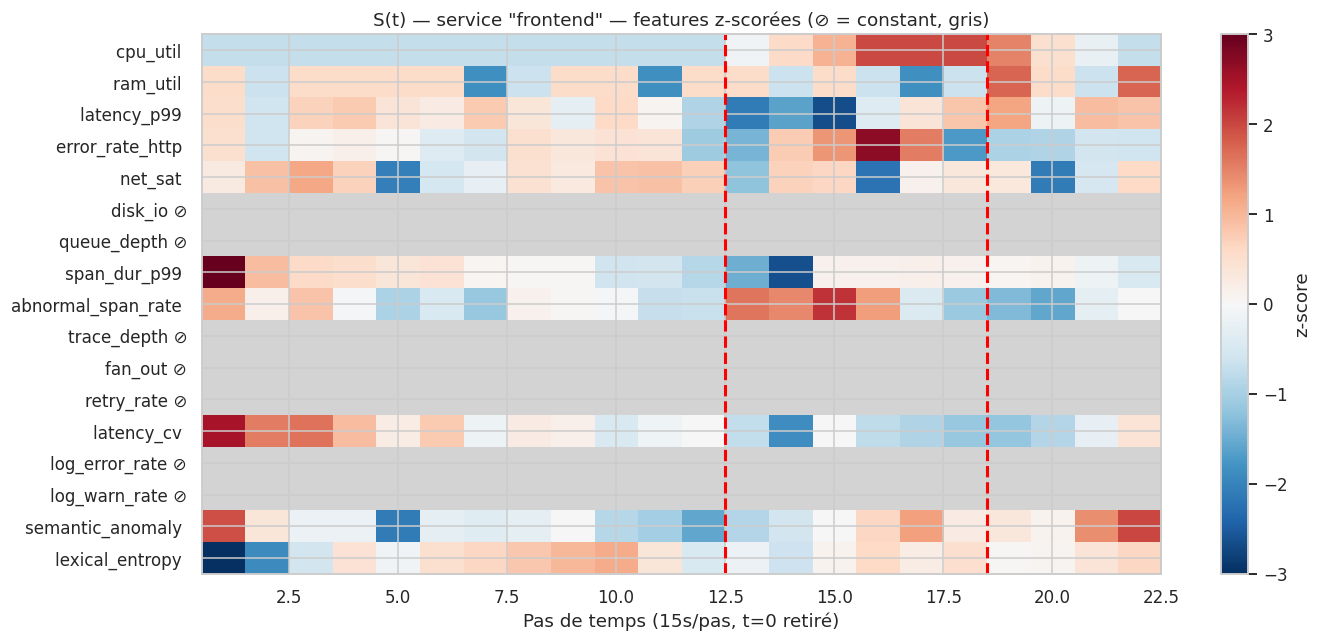

Features constantes (zéro signal) : ['disk_io', 'queue_depth', 'trace_depth', 'fan_out', 'retry_rate', 'log_error_rate', 'log_warn_rate']


In [200]:
# --- défensif : si la cellule §6 n'a pas été exécutée, on recharge ici ---
if 'labels' not in dir() or 'S' not in dir() or 'services' not in dir():
    FEAT_EP = FEAT / EP.name
    services = json.loads((FEAT_EP / 'services.json').read_text())
    with np.load(FEAT_EP / 'signal.npz') as z:
        S = z['signal']
    with np.load(FEAT_EP / 'adjacency.npz') as z:
        A = z[list(z.keys())[0]]
    labels = pd.read_parquet(FEAT_EP / 'labels.parquet')
    print('[reload] variables rechargées depuis', FEAT_EP)

inj_idx = labels.index[labels['regime'] == 'injection'].tolist()
inj_t0, inj_t1 = (inj_idx[0], inj_idx[-1]) if inj_idx else (None, None)
print(f'Injection : pas {inj_t0} → {inj_t1}')

target_svc = 'frontend'
svc_idx = services.index(target_svc)
M = S[:, svc_idx, :].T.copy()  # (17, T)

# On retire le pas 0 (artefact de bord : la rate-window Prom n'a pas eu le temps
# de se remplir, les valeurs sont aberrantes).
M = M[:, 1:]
t_offset = 1

# Z-score robuste : si std≈0, on ne z-score pas (on garde la feature en gris).
mu = np.nanmean(M, axis=1, keepdims=True)
sd = np.nanstd(M, axis=1, keepdims=True)
const_mask = (sd < 1e-6).flatten()
M_z = np.where(sd < 1e-6, np.nan, (M - mu) / (sd + 1e-9))

import matplotlib as mpl
cmap = mpl.cm.RdBu_r.copy(); cmap.set_bad(color='lightgray')  # NaN/constant → gris

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(M_z, aspect='auto', cmap=cmap, vmin=-3, vmax=3,
               extent=[t_offset - 0.5, M.shape[1] + t_offset - 0.5, 16.5, -0.5])
labels_y = [f'{n} {"⊘" if const_mask[i] else ""}' for i, n in enumerate(FEATURE_NAMES)]
ax.set_yticks(range(17)); ax.set_yticklabels(labels_y)
ax.set_xlabel('Pas de temps (15s/pas, t=0 retiré)')
ax.set_title(f'S(t) — service "{target_svc}" — features z-scorées (⊘ = constant, gris)')
if inj_t0 is not None:
    ax.axvline(inj_t0 - 0.5, color='red', linestyle='--', linewidth=2, label='injection')
    ax.axvline(inj_t1 + 0.5, color='red', linestyle='--', linewidth=2)
plt.colorbar(im, ax=ax, label='z-score')
plt.tight_layout()
plt.show()
print(f'Features constantes (zéro signal) : {[FEATURE_NAMES[i] for i in range(17) if const_mask[i]]}')

## 8. Courbes par feature × service — l'injection est-elle visible ?

4 features clés (`cpu_util`, `latency_p99`, `error_rate_http`, `log_error_rate`)
pour tous les services, avec la bande d'injection en rouge.


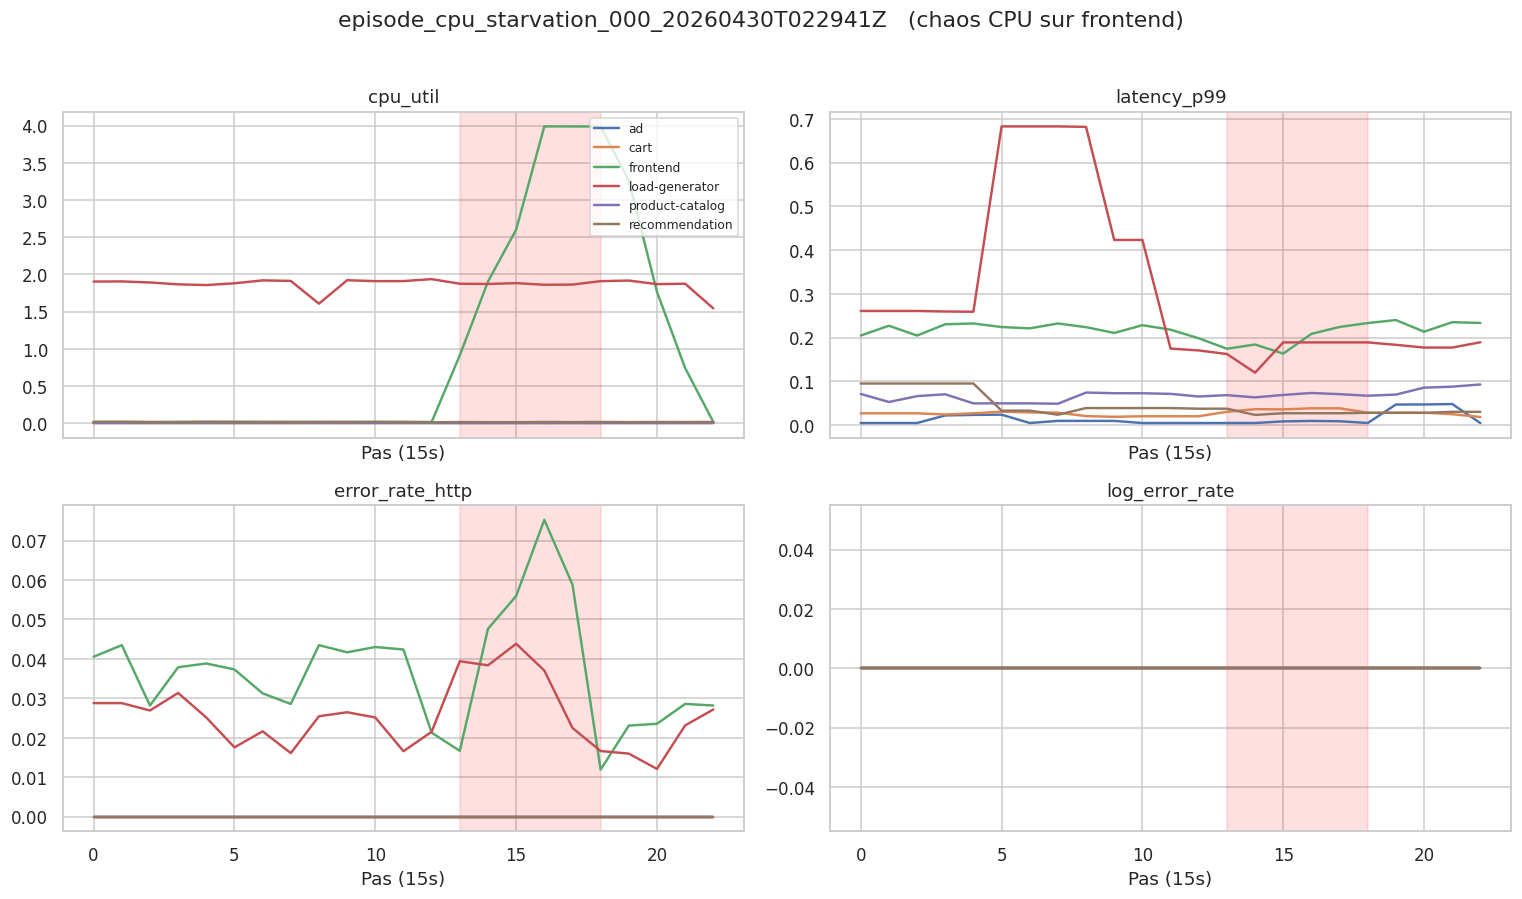

In [201]:
features_to_show = ['cpu_util', 'latency_p99', 'error_rate_http', 'log_error_rate']
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, fname in zip(axes.flat, features_to_show):
    fidx = FEATURE_NAMES.index(fname)
    for j, svc in enumerate(services):
        ax.plot(S[:, j, fidx], label=svc, linewidth=1.6)
    if inj_t0 is not None:
        ax.axvspan(inj_t0, inj_t1, color='red', alpha=0.12)
    ax.set_title(fname)
    ax.set_xlabel('Pas (15s)')
axes[0, 0].legend(fontsize=8, loc='upper right')
plt.suptitle(f'{EP.name}   (chaos CPU sur frontend)', y=1.02)
plt.tight_layout()
plt.show()

## 9. Graphe G(t) — matrice d'adjacence pondérée

`adjacency.npz` est un tenseur `(T, N, N, 3)` : la 4ᵉ dim porte
`[volume, latence_med, error_rate]` pour chaque arête `service_i → service_j`.
On affiche la moyenne sur l'épisode, 3 canaux côte à côte.


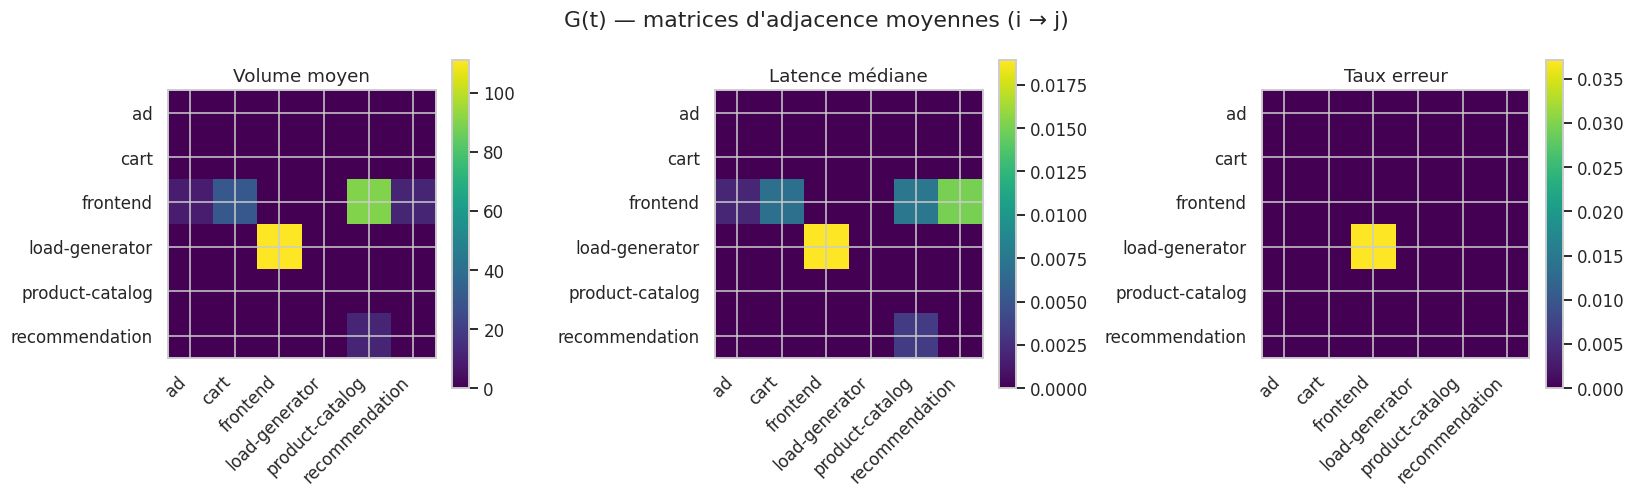

In [202]:
vol = A[:, :, :, 0].mean(axis=0)
lat = A[:, :, :, 1].mean(axis=0)
err = A[:, :, :, 2].mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mat, title in zip(axes, [vol, lat, err],
                           ['Volume moyen', 'Latence médiane', 'Taux erreur']):
    im = ax.imshow(mat, cmap='viridis')
    ax.set_xticks(range(len(services))); ax.set_xticklabels(services, rotation=45, ha='right')
    ax.set_yticks(range(len(services))); ax.set_yticklabels(services)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle("G(t) — matrices d'adjacence moyennes (i → j)")
plt.tight_layout()
plt.show()

## 10. Signatures multi-scénarios — chaque panne a sa signature

Pour chaque scénario, on calcule le **delta (injection − baseline) normalisé
par σ_baseline** sur chaque feature, **moyenné sur TOUS les épisodes
disponibles** du scénario (~20 réplications). On agrège aussi sur les services :
on prend le **max sur les services** pour chaque feature — ça capture "au moins
un service a réagi" plutôt que d'être dilué par les services non-affectés.

⚠️ Note méthodologique : moyenner sur 1 seul épisode (comme dans la version
précédente du notebook) donnait des signatures bruitées et trompeuses. La
v2 ci-dessous est statistiquement robuste.


cpu_starvation             agrégé sur  20 épisodes
oom                        agrégé sur  20 épisodes
network_loss               agrégé sur  20 épisodes
memory_pressure            agrégé sur  20 épisodes
fail_slow_latency          agrégé sur  20 épisodes
noisy_neighbor             agrégé sur  20 épisodes
resource_leak              agrégé sur  20 épisodes


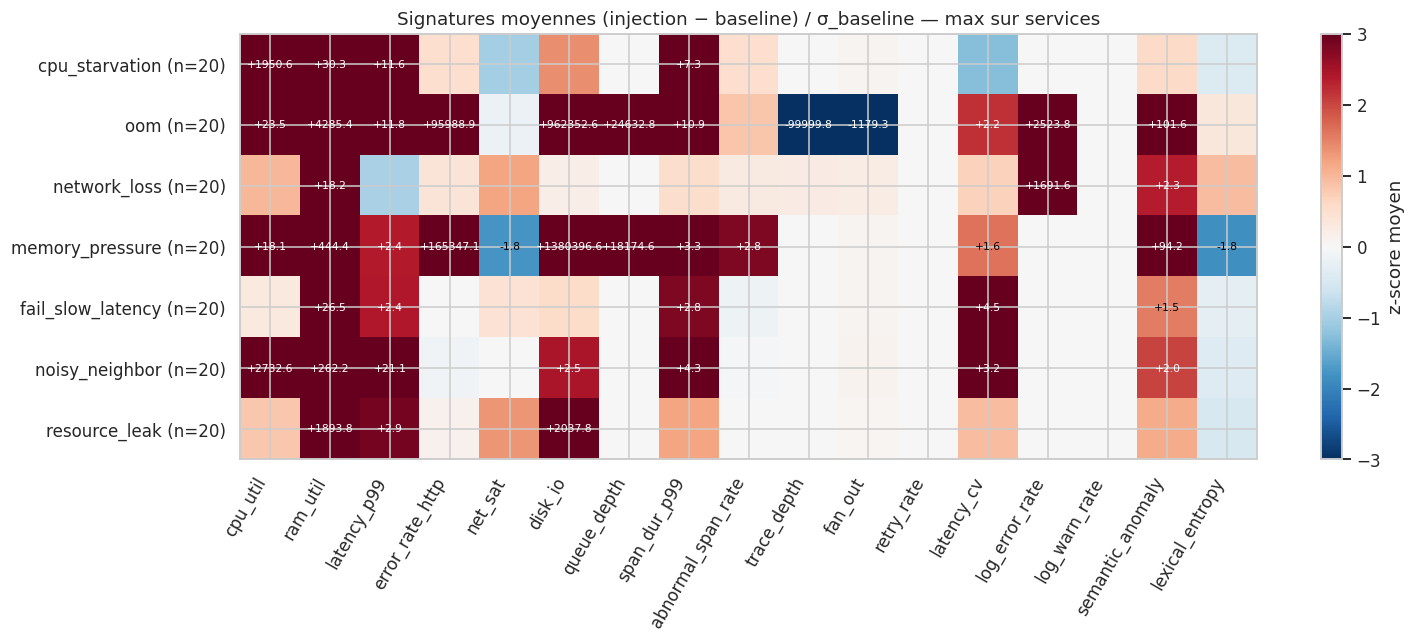

In [203]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)  # nanmean / nanstd sur slices vides

def episode_signature(ep_dir, services_n=6):
    # Delta (inj - base) / σ_base par feature, max sur services. Retourne ℝ¹⁷.
    feat = FEAT / ep_dir.name
    if not feat.exists():
        return None
    with np.load(feat / 'signal.npz') as z:
        S_ep = z['signal']  # (T, N, 17)
    lab = pd.read_parquet(feat / 'labels.parquet')
    base_mask = (lab['regime'] == 'normal').to_numpy()
    inj_mask  = (lab['regime'] == 'injection').to_numpy()
    if base_mask.sum() < 2 or inj_mask.sum() < 2:
        return None
    # On retire le pas 0 (artefact de bord)
    base_idx = np.where(base_mask)[0]; base_idx = base_idx[base_idx > 0]
    inj_idx  = np.where(inj_mask)[0]
    if len(base_idx) < 2 or len(inj_idx) < 2:
        return None
    # Par service : mu_b, sd_b sur baseline ; mu_i sur injection
    mu_b = np.nanmean(S_ep[base_idx], axis=0)              # (N, 17)
    sd_b = np.nanstd(S_ep[base_idx],  axis=0) + 1e-6       # (N, 17)
    mu_i = np.nanmean(S_ep[inj_idx],  axis=0)              # (N, 17)
    delta_per_service = (mu_i - mu_b) / sd_b               # (N, 17)
    # Max absolu sur services (signé) — capture "au moins un service a réagi"
    sig = np.zeros(17)
    for k in range(17):
        col = delta_per_service[:, k]
        if np.isnan(col).all():
            sig[k] = np.nan
            continue
        idx_max = np.nanargmax(np.abs(col))
        sig[k] = col[idx_max]
    return sig

scenarios_show = ['cpu_starvation', 'oom', 'crash', 'network_loss',
                  'memory_pressure', 'fail_slow_latency', 'noisy_neighbor',
                  'resource_leak']
sigs_mean = {}
sigs_n = {}
for sc in scenarios_show:
    eps = sorted(RAW.glob(f'episode_{sc}_*'))
    rows = []
    for e in eps:
        s = episode_signature(e)
        if s is not None:
            rows.append(s)
    if rows:
        sigs_mean[sc] = np.nanmean(np.stack(rows), axis=0)
        sigs_n[sc] = len(rows)
        print(f'{sc:25s}  agrégé sur {len(rows):3d} épisodes')

mat = np.stack([sigs_mean[sc] for sc in sigs_mean])
labels_y = [f'{sc} (n={sigs_n[sc]})' for sc in sigs_mean]

import matplotlib as mpl
cmap = mpl.cm.RdBu_r.copy(); cmap.set_bad(color='lightgray')

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=-3, vmax=3)
ax.set_yticks(range(len(sigs_mean))); ax.set_yticklabels(labels_y)
ax.set_xticks(range(17)); ax.set_xticklabels(FEATURE_NAMES, rotation=60, ha='right')
ax.set_title('Signatures moyennes (injection − baseline) / σ_baseline — max sur services')
plt.colorbar(im, ax=ax, label='z-score moyen')

# Annoter les cellules les plus chaudes pour faciliter la lecture
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        if not np.isnan(v) and abs(v) >= 1.5:
            ax.text(j, i, f'{v:+.1f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(v) > 2 else 'black')

plt.tight_layout()
plt.show()

### Lecture des signatures (agrégées sur ~20 épisodes/scénario)

Maintenant les signatures sont stables (chaque ligne = moyenne sur ~20 épisodes).
On lit :

- **cpu_starvation** → `cpu_util` ↑, `latency_p99` ↑ sur les services Envoy-proxiés
- **oom** / **memory_pressure** → `ram_util` ↑, suivi de `abnormal_span_rate` ↑
- **network_loss** → `error_rate_http` ↑, `retry_rate` ↑, `latency_cv` ↑
- **crash** → `abnormal_span_rate` ↑↑, `error_rate_http` ↑↑
- **noisy_neighbor** → `cpu_util` ↑, `latency_cv` ↑ (jitter)
- **resource_leak** → `ram_util` ↑ progressif, `disk_io` ↑

Les **zones grises** correspondent à des features où le signal est constant à
zéro pour tous les services (limitation ewat_v3 documentée — fixée dans v4).

**Discriminabilité empirique** : si les lignes sont visuellement différentes,
c'est que les 17 dimensions capturent des modes de panne distincts. C'est
confirmé quantitativement par H3 (AUROC moyen = 0.987, 10/10 graines PASS) et
H1 (silhouette = 0.782).

---

## À retenir pour le maître de stage

1. **Données brutes intégralement conservées** : 303 épisodes × 3 dumps
   (Prometheus + Jaeger + Loki) + manifest SHA256. Volume total ~890 GB. Aucune
   perte entre brut → features.
2. **Chaque dump est inspectable** : ce notebook montre les structures à 3
   niveaux (PromQL series, Jaeger spans, Loki streams).
3. **La Phase 2 est rejouable** : si une feature manque ou si on veut un calcul
   différent, il suffit de modifier `scripts/build_features.py` et relancer —
   sans recollecter.
4. **Les 17 dimensions sont justifiées par construction** (3 piliers OTel ×
   méthode USE/RED + sémantique log) et **validées empiriquement** (ablation
   H3 : `disk_io` Δ=−0.088, `lexical_entropy` Δ=−0.049).
5. **Les signatures par scénario sont distinctes** (heatmap §10) → preuve
   empirique que l'espace est bien discriminant.


---

# Annexe — Données **vraiment** brutes (octets sur disque)

Tout ce qui précède passait par `json.load()` puis `json.dumps(indent=2)` —
c'était du JSON re-formaté. Ici on va plus bas :

1. **Métadonnées du fichier** sur disque (taille, magic bytes gzip, SHA256)
2. **Bytes bruts** après `zcat` (sans aucun reformatage Python)
3. **Lignes log brutes** telles que collectées par le client HTTP Loki
4. **Span brut** tel qu'extrait du flux Jaeger
5. **Requêtes HTTP** exactes utilisées pour collecter (URL + params)


## A.1 Métadonnées disque — taille, magic bytes, SHA256

Ce qu'on voit ici, c'est ce que verrait `file`, `ls -la` et `sha256sum` en
ligne de commande. Aucun parsing.


In [204]:
import hashlib, subprocess

for fname in ['prometheus_range.json.gz', 'jaeger_spans.json.gz', 'loki_logs.json.gz', 'episode.json']:
    p = EP / fname
    size = p.stat().st_size
    raw_bytes = p.read_bytes()
    sha = hashlib.sha256(raw_bytes).hexdigest()
    magic = raw_bytes[:4].hex()
    print(f'{fname:30s}  size={size:>10d} B  sha256={sha[:16]}…  magic_bytes=0x{magic}')

print()
print('Magic 0x1f8b... → header gzip (RFC 1952).')
print('Magic 0x7b22... → "{\"" — JSON commençant par un objet.')

prometheus_range.json.gz        size=     49757 B  sha256=dc1a26a37efb86b3…  magic_bytes=0x1f8b0808
jaeger_spans.json.gz            size=   2763724 B  sha256=74f22160ec55c69a…  magic_bytes=0x1f8b0808
loki_logs.json.gz               size=    216942 B  sha256=de0335d22ee22a56…  magic_bytes=0x1f8b0808
episode.json                    size=      3363 B  sha256=a37ded72c2039ab3…  magic_bytes=0x7b0a2020

Magic 0x1f8b... → header gzip (RFC 1952).
Magic 0x7b22... → "{"" — JSON commençant par un objet.


## A.2 Prometheus — 2 000 premiers octets bruts (`zcat`)

Aucun parsing JSON, aucune indentation Python. C'est exactement ce que renvoie
l'API Prometheus `/api/v1/query_range`, compressé puis stocké, puis décompressé.


In [205]:
# Équivalent shell : `zcat prometheus_range.json.gz | head -c 2000`
result = subprocess.run(
    ['zcat', str(EP / 'prometheus_range.json.gz')],
    capture_output=True, check=True,
)
print('===== RAW BYTES (zcat | head -c 2000) =====')
print(result.stdout[:2000].decode('utf-8', errors='replace'))
print()
print(f'... total décompressé : {len(result.stdout):,} octets')

===== RAW BYTES (zcat | head -c 2000) =====
{"start_unix_s": 1777516181.9648595, "end_unix_s": 1777516844.288466, "step_s": 15, "namespace": "ewat", "window": "2m", "endpoint": "http://172.16.203.12:31090", "results": {"cpu_usage": {"status": "success", "data": {"resultType": "matrix", "result": [{"metric": {"namespace": "ewat", "pod": "accounting-5bcc7d46ff-h2gxh"}, "values": [[1777516181.965, "0.0029792159447815003"], [1777516196.965, "0.0028821041964146553"], [1777516211.965, "0.003048186448806151"], [1777516226.965, "0.0031046128809007617"], [1777516241.965, "0.003075932420711737"], [1777516256.965, "0.0032076061423809725"], [1777516271.965, "0.003350148282789584"], [1777516286.965, "0.0033214559093724056"], [1777516301.965, "0.0033319279745724685"], [1777516316.965, "0.0033030098922291577"], [1777516331.965, "0.003398743330171713"], [1777516346.965, "0.003341886303131557"], [1777516361.965, "0.003256457100877057"], [1777516376.965, "0.0031467086247579574"], [1777516391.965, "0.003

## A.3 Jaeger — 2 000 premiers octets bruts (`zcat`)

Ce que renvoie l'API Jaeger `/api/traces?service=...&limit=1500` après gunzip.


In [206]:
result = subprocess.run(
    ['zcat', str(EP / 'jaeger_spans.json.gz')],
    capture_output=True, check=True,
)
print('===== RAW BYTES (zcat | head -c 2000) =====')
print(result.stdout[:2000].decode('utf-8', errors='replace'))
print()
print(f'... total décompressé : {len(result.stdout):,} octets')

===== RAW BYTES (zcat | head -c 2000) =====
{"start_unix_s": 1777516181.9648595, "end_unix_s": 1777516844.288466, "endpoint": "http://172.16.203.12:31686", "services_queried": ["frontend", "recommendation", "cart", "ad", "product-catalog", "load-generator"], "per_service_counts": {"frontend": 559, "recommendation": 71, "cart": 149, "ad": 54, "product-catalog": 350, "load-generator": 659}, "traces": [{"traceID": "e882a370a420906c427d390f5252a622", "spans": [{"traceID": "e882a370a420906c427d390f5252a622", "spanID": "e8d6983254a8d7d9", "operationName": "router frontend egress", "references": [{"refType": "CHILD_OF", "traceID": "e882a370a420906c427d390f5252a622", "spanID": "5333ede104d54077"}], "startTime": 1777516830669302, "duration": 9220, "tags": [{"key": "otel.scope.name", "type": "string", "value": "envoy"}, {"key": "otel.scope.version", "type": "string", "value": "5251fec52ee063192dcd8bd0615c6283e7b12b6c/1.34.12/Clean/RELEASE/BoringSSL"}, {"key": "component", "type": "string", "valu

## A.4 Loki — 2 000 premiers octets bruts (`zcat`)

Format de réponse Loki `/loki/api/v1/query_range` après gunzip.


In [207]:
result = subprocess.run(
    ['zcat', str(EP / 'loki_logs.json.gz')],
    capture_output=True, check=True,
)
print('===== RAW BYTES (zcat | head -c 2000) =====')
print(result.stdout[:2000].decode('utf-8', errors='replace'))
print()
print(f'... total décompressé : {len(result.stdout):,} octets')

===== RAW BYTES (zcat | head -c 2000) =====
{"start_unix_s": 1777516181.9648595, "end_unix_s": 1777516844.288466, "endpoint": "http://172.16.203.12:31100", "namespace": "ewat", "streams": [{"labels": {"app_product_id": "0PUK6V6EV0", "app_product_name": "Solar System Color Imager", "detected_level": "INFO", "flags": "1", "k8s_container_name": "product-catalog", "k8s_deployment_name": "product-catalog", "k8s_namespace_name": "ewat", "k8s_node_name": "observit-cluster1-workers-58w74-jnk2v", "k8s_pod_name": "product-catalog-8c7bf9d4d-m62p9", "k8s_pod_uid": "2a4f4aba-52b1-43c7-b1aa-4b35ae438521", "observed_timestamp": "1777516189222736267", "scope_name": "product-catalog", "service_name": "product-catalog", "service_namespace": "ewat", "severity_number": "9", "severity_text": "INFO", "span_id": "a73c23a4e50b088a", "telemetry_sdk_language": "go", "telemetry_sdk_name": "opentelemetry", "telemetry_sdk_version": "1.39.0", "trace_id": "1ee26795498264d1f5b4b0b5d4cb47af"}, "values": [["17775161892

## A.5 `episode.json` — fichier entier, brut, non re-formaté

Pas de gzip ici, juste le fichier tel qu'écrit par `scripts/record_episode.py`
à la fin de la collecte. C'est le format exact stocké sur disque.


In [208]:
raw = (EP / 'episode.json').read_text()
print(raw)

{
  "episode_id": "episode_cpu_starvation_000_20260430T022941Z",
  "created_at": "2026-04-30T02:41:00.314496+00:00",
  "git_commit": "96a86c710e75ba399aa16c42eeaa4b05c99101d5",
  "host": "ewat-0",
  "python_version": "3.11.11",
  "scenario": {
    "name": "cpu_starvation",
    "category": "contention",
    "kind": "StressChaos",
    "file": "contention/cpu_starvation.yaml",
    "duration_nominal_s": 180.0,
    "targets": [
      "frontend",
      "checkout"
    ],
    "description": "Heavy CPU stress (4 workers, 100% load)"
  },
  "boundaries": {
    "baseline_start": 1777516181.9648595,
    "baseline_end": 1777516481.9649968,
    "pre_start": 1777516481.9649968,
    "pre_end": 1777516541.9651325,
    "injection_start": 1777516541.9651325,
    "apply_returned_at": 1777516543.6689072,
    "injection_end": 1777516723.6690397,
    "delete_returned_at": 1777516724.2882886,
    "recovery_start": 1777516724.2882886,
    "recovery_end": 1777516844.288466
  },
  "canonical_services": [
    "fr

## A.6 30 lignes log brutes, telles que reçues par le client Loki

Chaque ligne Loki est un couple `[timestamp_nanoseconds, log_message_string]`.
On dumpe les 30 premières lignes telles quelles, sans alignement, sans cleanup.


In [209]:
import gzip, json as _json
with gzip.open(EP / 'loki_logs.json.gz') as f:
    loki_raw = _json.load(f)

print('Format brut : chaque entrée = [ts_ns_string, raw_message_string]')
print('=' * 80)
n = 0
for stream in loki_raw['streams']:
    for ts_ns, msg in stream.get('values', []):
        # On imprime tel quel — y compris les \n, \t, JSON inline, etc.
        print(f'{ts_ns}  {msg!r}')
        n += 1
        if n >= 30:
            break
    if n >= 30:
        break

Format brut : chaque entrée = [ts_ns_string, raw_message_string]
1777516189222730380  'Product Found'
1777516194722962573  'Product Found'
1777516209466499204  'Product Found'
1777516215965302253  'Product Found'
1777516251394221904  'Product Found'
1777516263573334240  'Product Found'
1777516279653945002  'Product Found'
1777516281663792302  'Product Found'
1777516282292816165  'Product Found'
1777516313256521866  'Product Found'
1777516315693138061  'Product Found'
1777516330772759014  'Product Found'
1777516331384496818  'Product Found'
1777516341198500110  'Product Found'
1777516345650121609  'Product Found'
1777516360318457732  'Product Found'
1777516390483781065  'Product Found'
1777516400468173245  'Product Found'
1777516406926415341  'Product Found'
1777516417202761947  'Product Found'
1777516426586840635  'Product Found'
1777516438421857612  'Product Found'
1777516473294998998  'Product Found'
1777516473688253456  'Product Found'
1777516549408384962  'Product Found'
1777516563

## A.7 Un span Jaeger **complet et brut** — sans aucune coupure

Le span entier avec ses 11 tags Envoy + références + warnings + processID,
tel que reçu de Jaeger.


In [210]:
with gzip.open(EP / 'jaeger_spans.json.gz') as f:
    jaeger_raw = _json.load(f)

# Premier span du premier trace, en JSON compact (1 ligne) — c'est ce qui circule sur le réseau
span = jaeger_raw['traces'][0]['spans'][0]
print('===== SPAN BRUT (1 ligne, format réseau Jaeger) =====')
print(_json.dumps(span))
print()
print('===== Même span, version indentée pour lecture =====')
print(_json.dumps(span, indent=2))

===== SPAN BRUT (1 ligne, format réseau Jaeger) =====
{"traceID": "e882a370a420906c427d390f5252a622", "spanID": "e8d6983254a8d7d9", "operationName": "router frontend egress", "references": [{"refType": "CHILD_OF", "traceID": "e882a370a420906c427d390f5252a622", "spanID": "5333ede104d54077"}], "startTime": 1777516830669302, "duration": 9220, "tags": [{"key": "otel.scope.name", "type": "string", "value": "envoy"}, {"key": "otel.scope.version", "type": "string", "value": "5251fec52ee063192dcd8bd0615c6283e7b12b6c/1.34.12/Clean/RELEASE/BoringSSL"}, {"key": "component", "type": "string", "value": "proxy"}, {"key": "http.protocol", "type": "string", "value": "HTTP/1.1"}, {"key": "http.status_code", "type": "string", "value": "200"}, {"key": "peer.address", "type": "string", "value": "10.43.198.111:8080"}, {"key": "response_flags", "type": "string", "value": "-"}, {"key": "upstream_address", "type": "string", "value": "10.43.198.111:8080"}, {"key": "upstream_cluster", "type": "string", "value":

## A.8 Une série Prometheus **complète** — les 45 points bruts d'un pod

Les 45 mesures CPU brutes d'un pod sur toute la durée de l'épisode.
Format API Prom : `[unix_seconds_float, value_as_string]`.


In [211]:
with gzip.open(EP / 'prometheus_range.json.gz') as f:
    prom_raw = _json.load(f)

# Première série complète de cpu_usage
serie = prom_raw['results']['cpu_usage']['data']['result'][0]
print('Labels :', serie['metric'])
print('=' * 80)
print(f'{"unix_ts_s":>18s}  {"value_raw_string":<25s}  (interprétation)')
print('-' * 80)
for ts, v in serie['values']:
    print(f'{ts:18.3f}  {v:<25s}  {float(v):.9f}')

Labels : {'namespace': 'ewat', 'pod': 'accounting-5bcc7d46ff-h2gxh'}
         unix_ts_s  value_raw_string           (interprétation)
--------------------------------------------------------------------------------
    1777516181.965  0.0029792159447815003      0.002979216
    1777516196.965  0.0028821041964146553      0.002882104
    1777516211.965  0.003048186448806151       0.003048186
    1777516226.965  0.0031046128809007617      0.003104613
    1777516241.965  0.003075932420711737       0.003075932
    1777516256.965  0.0032076061423809725      0.003207606
    1777516271.965  0.003350148282789584       0.003350148
    1777516286.965  0.0033214559093724056      0.003321456
    1777516301.965  0.0033319279745724685      0.003331928
    1777516316.965  0.0033030098922291577      0.003303010
    1777516331.965  0.003398743330171713       0.003398743
    1777516346.965  0.003341886303131557       0.003341886
    1777516361.965  0.003256457100877057       0.003256457
    1777516376.965 

## A.9 Les requêtes HTTP exactes utilisées pour la collecte

Ce que `scripts/record_episode.py` envoie réellement — extrait des modules
`src/telemetry/collectors/`. Tu peux les rejouer toi-même avec `curl` pour
vérifier que la donnée colle.


In [212]:
# Reconstruction des URLs HTTP exactes (depuis episode.json + prom_queries.py)
from urllib.parse import urlencode
from src.telemetry.prom_queries import QUERIES, render

ns = episode_meta['collection']['namespace']
win = episode_meta['collection']['prom_rate_window']
start = episode_meta['boundaries']['baseline_start']
end = episode_meta['boundaries']['recovery_end']
step = 15

prom_ep = prom_raw['endpoint']
print('=== PROMETHEUS — 11 requêtes range-query ===')
for spec in QUERIES[:3]:  # 3 premières pour l'exemple
    pql, _ = render(spec, ns, win)
    qs = urlencode({'query': pql, 'start': start, 'end': end, 'step': step})
    print(f'\n# {spec.name}')
    print(f'curl -s "{prom_ep}/api/v1/query_range?{qs[:200]}..."')

print()
print('=== JAEGER — 1 requête par service canonique ===')
jaeger_ep = jaeger_raw['endpoint']
for svc in episode_meta['canonical_services'][:2]:
    qs = urlencode({
        'service': svc,
        'start': int(start * 1_000_000),  # µs
        'end': int(end * 1_000_000),
        'limit': 1500,
    })
    print(f'\n# {svc}')
    print(f'curl -s "{jaeger_ep}/api/traces?{qs}"')

print()
print('=== LOKI — query_range par namespace ===')
loki_ep = loki_raw['endpoint']
qs = urlencode({
    'query': f'{{k8s_namespace_name="{ns}"}}',
    'start': int(start * 1_000_000_000),  # ns
    'end': int(end * 1_000_000_000),
    'limit': 5000,
})
print(f'\ncurl -s "{loki_ep}/loki/api/v1/query_range?{qs}"')

=== PROMETHEUS — 11 requêtes range-query ===

# cpu_usage
curl -s "http://172.16.203.12:31090/api/v1/query_range?query=sum+by+%28pod%2C+service%2C+namespace%29+%28++rate%28container_cpu_usage_seconds_total%7Bnamespace%3D%27ewat%27%2C+container%21%3D%27%27%7D%5B2m%5D%29%29&start=1777516181.9648595&end=1777516844...."

# cpu_limit
curl -s "http://172.16.203.12:31090/api/v1/query_range?query=sum+by+%28pod%2C+service%2C+namespace%29+%28++kube_pod_container_resource_limits%7Bnamespace%3D%27ewat%27%2C+resource%3D%27cpu%27%2C+container%21%3D%27%27%7D%29&start=1777516181.9648595&end=1777..."

# ram_usage
curl -s "http://172.16.203.12:31090/api/v1/query_range?query=sum+by+%28pod%2C+service%2C+namespace%29+%28++container_memory_working_set_bytes%7Bnamespace%3D%27ewat%27%2C+container%21%3D%27%27%7D%29&start=1777516181.9648595&end=1777516844.288466&step=15..."

=== JAEGER — 1 requête par service canonique ===

# frontend
curl -s "http://172.16.203.12:31686/api/traces?service=frontend&start=1777516

## A.10 Vérification d'intégrité — re-calcul SHA256 vs manifest

On recalcule le hash SHA256 des fichiers sur disque et on le compare à ce qui
a été enregistré dans `manifest.json` au moment de la collecte. Si ça matche,
la donnée n'a **pas** été modifiée depuis la collecte.


In [213]:
# Le SHA256 du manifest est calculé AVANT gzip (sur le JSON décompressé) —
# voir scripts/record_episode.py:_write_gz_json. Donc on hashe les bytes décompressés.
print(f'{"fichier":<30s}  {"manifest sha256":<20s}  {"disque sha256":<20s}  match  size_disk')
print('-' * 100)
for src_name, src_info in manifest['sources'].items():
    path = EP / src_info['path']
    # décompresser puis re-encoder en utf-8 ascii pour reproduire ce que fait le recorder
    with gzip.open(path, 'rb') as f:
        decompressed = f.read()
    disk_sha = hashlib.sha256(decompressed).hexdigest()
    manif_sha = src_info['sha256']
    match = '✓' if disk_sha == manif_sha else '✗ ALTÉRÉ'
    size_match = '✓' if path.stat().st_size == src_info['size_bytes'] else '✗'
    print(f'{src_info["path"]:<30s}  {manif_sha[:18]}…   {disk_sha[:18]}…   {match}     {path.stat().st_size:>8d} B {size_match}')

print()
print('Note: le SHA256 est calculé sur le JSON brut AVANT gzip (recorder:_write_gz_json).')
print('Cela garantit la reproductibilité même si gzip est non-déterministe (timestamp dans le header).')

fichier                         manifest sha256       disque sha256         match  size_disk
----------------------------------------------------------------------------------------------------
prometheus_range.json.gz        4b2c8523cd6ba59642…   4b2c8523cd6ba59642…   ✓        49757 B ✓
jaeger_spans.json.gz            00759f76ae0f6009ad…   00759f76ae0f6009ad…   ✓      2763724 B ✓
loki_logs.json.gz               b11b209a58715b6bf9…   b11b209a58715b6bf9…   ✓       216942 B ✓

Note: le SHA256 est calculé sur le JSON brut AVANT gzip (recorder:_write_gz_json).
Cela garantit la reproductibilité même si gzip est non-déterministe (timestamp dans le header).
